In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [4]:
data = {
    "Studied_Hours" : [1,2,2,3,3,4,5,6,6,7],
    "Sleep" : [8,7,6,8,6,7,5,6,4,5],
    "Passed" : [0,0,0,0,1,1,1,1,1,1]
}

df = pd.DataFrame(data)
df

,Studied_Hours,Sleep,Passed
0,1,8,0
1,2,7,0
2,2,6,0
3,3,8,0
4,3,6,1
5,4,7,1
6,5,5,1
7,6,6,1
8,6,4,1
9,7,5,1


In [5]:
df.head()

,Studied_Hours,Sleep,Passed
0,1,8,0
1,2,7,0
2,2,6,0
3,3,8,0
4,3,6,1


In [9]:
df.shape

(10, 3)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Studied_Hours  10 non-null     int64
 1   Sleep          10 non-null     int64
 2   Passed         10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


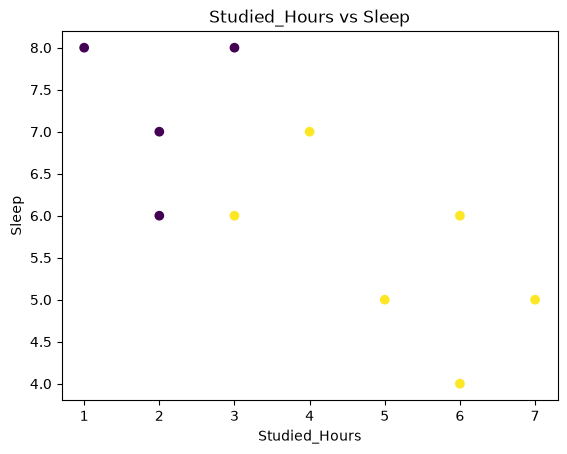

In [12]:
plt.scatter(
    df["Studied_Hours"],
    df["Sleep"],
    c=df["Passed"]
)

plt.xlabel("Studied_Hours")
plt.ylabel("Sleep")
plt.title("Studied_Hours vs Sleep")
plt.show()

In [13]:
x = df[["Studied_Hours", "Sleep"]]
y = df["Passed"]

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.linear_model import Perceptron

In [17]:
model = Perceptron()

In [20]:
model.fit(x_train, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [22]:
y_pred = model.predict(x_test)
y_pred

array([0, 1])

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [24]:
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [[17. -7.]]
Bias: [1.]


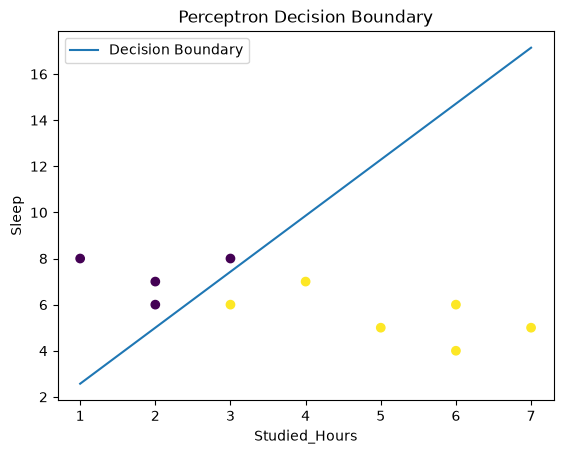

In [28]:
x_values = np.linspace(
    df["Studied_Hours"].min(),
    df["Studied_Hours"].max(),
    100
)

y_values = (17 * x_values + 1)/7

plt.scatter(
    df["Studied_Hours"],
    df["Sleep"],
    c=df["Passed"]
)

plt.plot(
    x_values,
    y_values,
    label="Decision Boundary"
)

plt.xlabel("Studied_Hours")
plt.ylabel("Sleep")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.show()

In [32]:
results = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})
results

,Actual,Predicted
2,0,0
6,1,1


In [43]:
new_student = [[3.5, 8]]
model.predict(new_student)

C:\Users\Morteza\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


array([1])